/tmp/ipykernel_8510/3614220273.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  polygon = plt.Polygon(vertices, closed = True, fill = True, color = 'lightblue', edgecolor = 'black')


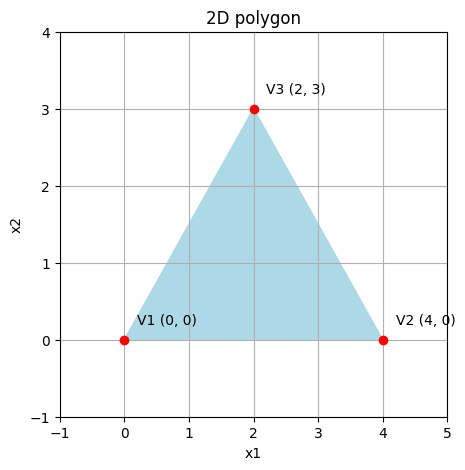

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize = (5, 5))

vertices = np.array(
    [
        [0, 0],
        [4, 0],
        [2, 3]
    ]
)

polygon = plt.Polygon(vertices, closed = True, fill = True, color = 'lightblue', edgecolor = 'black')

ax.add_patch(polygon)
ax.plot(vertices[:, 0], vertices[:, 1], 'ro')

for i, (x, y) in enumerate(vertices):
  ax.text(x + 0.2, y + 0.2, f'V{i+1} ({x}, {y})')

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 4)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('2D polygon')
ax.grid(True)

(0.0, 1.2)

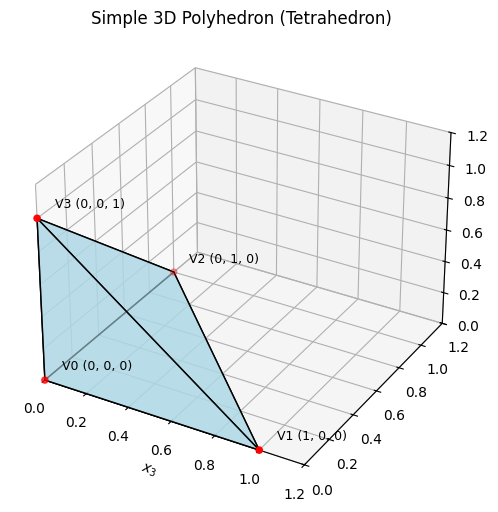

In [ ]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection = '3d') # 1 row, 1 column, first and only subplot
# projection '3d' tell matplotlib to use a 3d coordinate system

# [x, y, y] is a single point in 3d space

# 4 vertices in a tetrahedron
vertices = np.array([
    [0, 0, 0], # vertex 0: origin
    [1, 0, 0], # vertex 1: along x-axis
    [0, 1, 0], # vertex 2: along y-axis
    [0, 0, 1]  # vertex 3: along z-axis
])

faces = [
    [0, 1, 2], # base triangle
    [0, 1, 3], # side face
    [0, 2, 3], # side face
    [1, 2, 3] # top face
]

# poly3d is a list of faces, where each face is a lsit of 3D points

poly3d = [[vertices[vert_id] for vert_id in face] for face in faces]

# this is a 3d polygon collection that can be added to the axes

ax.add_collection(
    Poly3DCollection(
        poly3d,
        facecolors = 'lightblue',
        edgecolors = 'black',
        linewidths = 1,
        alpha = 0.6
    )
)

ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], color = 'red')

for i, v in enumerate(vertices):
  ax.text(
      v[0] + 0.05,
      v[1] + 0.05,
      v[2] + 0.05,
      f'V{i} ({v[0]}, {v[1]}, {v[2]})',
      fontsize = 9
  )

ax.set_xlabel('$x_1$')
ax.set_xlabel('$x_2$')
ax.set_xlabel('$x_3$')

ax.set_title("Simple 3D Polyhedron (Tetrahedron)")

ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1.2)
ax.set_zlim(0, 1.2)

# Task 1:
*   Apply linprog, simplex algorithm to solve this optimization problem
*   Construct a 3D object and mark the feasible region on the plot
*   Maximize: $2x_1+3x_2+x_4 = z$
*   Subject to: $2x_1+x_2+x_3 \leq 4$
*   $x_1,x_2,x_3 \ge 0$
*   Explore all the possible combinations of $x_1, x_2, x_3$ through a 3D grid



In [ ]:
from matplotlib.patches import Patch
from scipy.optimize import linprog

In [ ]:
c = [-2, -3, -1]

A = [[2, 1, 1]]
b = [4]

bounds = [(0, None), (0, None), (0, None)]

model = linprog(c, A_ub = A, b_ub = b, bounds = bounds, method = 'simplex')

/tmp/ipykernel_8510/1447422431.py:8: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  model = linprog(c, A_ub = A, b_ub = b, bounds = bounds, method = 'simplex')


In [ ]:
vertices = np.array(
    [
        [0, 0, 0], # origin
        [2, 0, 0], # x1
        [0, 4, 0], # x2
        [0, 0, 4]  # x3
    ]
)

faces = [
    [0, 1, 2], # base triangle
    [0, 1, 3],
    [0, 2, 3],
    [1, 2, 3]
]

face_colors = ['yellow', 'cyan', 'magenta', 'orange']

face_alpha = [0.2, 0.4, 0.6, 0.8]

In [ ]:
feasible_points = []

# create 30 steps between the limits of the axis
for x1 in np.linspace(0, 2, 30):
  for x2 in np.linspace(0, 4, 30):
    for x3 in np.linspace(0, 4, 30):

      if 2*x1 + x2 + x3 <= 4:
        feasible_points.append([x1, x2, x3])

feasible_points = np.array(feasible_points)

In [ ]:
feasible_points

array([[0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.13793103],
       [0.        , 0.        , 0.27586207],
       ...,
       [1.93103448, 0.        , 0.13793103],
       [1.93103448, 0.13793103, 0.        ],
       [2.        , 0.        , 0.        ]])

/tmp/ipykernel_8510/3800889625.py:6: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  model = linprog(c, A_ub = A, b_ub = b, bounds = bounds, method = 'simplex')


Text(0.5, 0.92, 'Convex hull optimization')

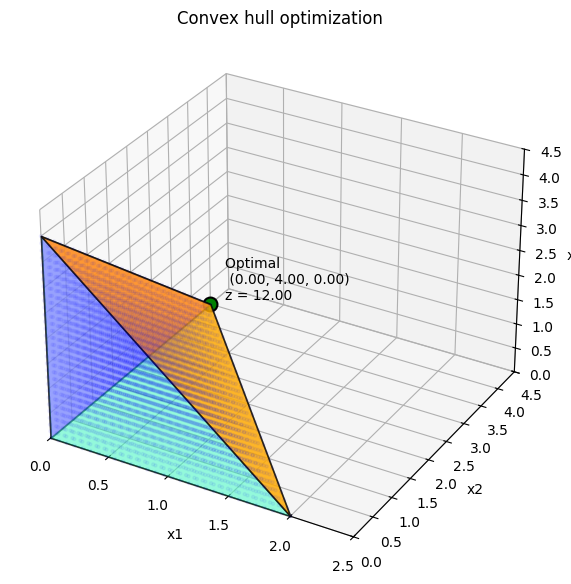

In [ ]:
c = [-2, -3, -1]
A = [[2, 1, 1]]
b = [4]
bounds = [(0, None), (0, None), (0, None)]

model = linprog(c, A_ub = A, b_ub = b, bounds = bounds, method = 'simplex')

vertices = np.array([
    [0, 0, 0], # origin point, all variables are 0
    [2, 0, 0], # x2 = x3 = 0
    [0, 4, 0], # x1 = x3 = 0
    [0, 0, 4], # x1 = x2 = 0
    ])

faces = [
    [0, 1, 2], # x1-x2
    [0, 1, 3], # x1-x3
    [0, 2, 3], # x2-x3
    [1, 2, 3] # constraint plane
]

faces_colors = ['yellow', 'cyan', 'magenta', 'orange']
face_alpha = [0.2, 0.4, 0.6, 0.8]

feasible_points = []
for x1 in np.linspace(0, 2, 30):
    for x2 in np.linspace(0, 4, 30):
        for x3 in np.linspace(0, 4, 30):
            if 2*x1 + x2 + x3 <= 4:
                feasible_points.append([x1, x2, x3])

feasible_points = np.array(feasible_points)

fig = plt.figure(figsize = (8, 7))
ax = fig.add_subplot(111, projection = '3d')

for (face, color, alpha) in zip(faces, faces_colors, face_alpha):
    poly = [vertices[i] for i in face]
    ax.add_collection3d(Poly3DCollection([poly], alpha = alpha, facecolor = color, edgecolor = 'black', linewidths = 1.2))

ax.scatter(feasible_points[:, 0], feasible_points[:, 1], feasible_points[:, 2], color = 'blue', alpha = 0.05, s = 5)

if model.success and len(model.x) == 3:
    x1, x2, x3 = model.x

    ax.scatter([x1], [x2], [x3], color = 'green', s = 100, edgecolor = 'black', linewidths = 1.5, label = 'Optimal solution')
    ax.text(x1 + 0.1, x2 + 0.1, x3 + 0.1, f'Optimal \n ({x1:.2f}, {x2:.2f}, {x3:.2f}) \nz = {-model.fun:.2f}', fontsize = 10)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
ax.set_xlim(0, 2.5)
ax.set_ylim(0, 4.5)
ax.set_zlim(0, 4.5)
ax.set_title('Convex hull optimization')

# Task 2:
* visualize the object from the previous example from 3 different angles (perspectives)
* keep the results from the previous task

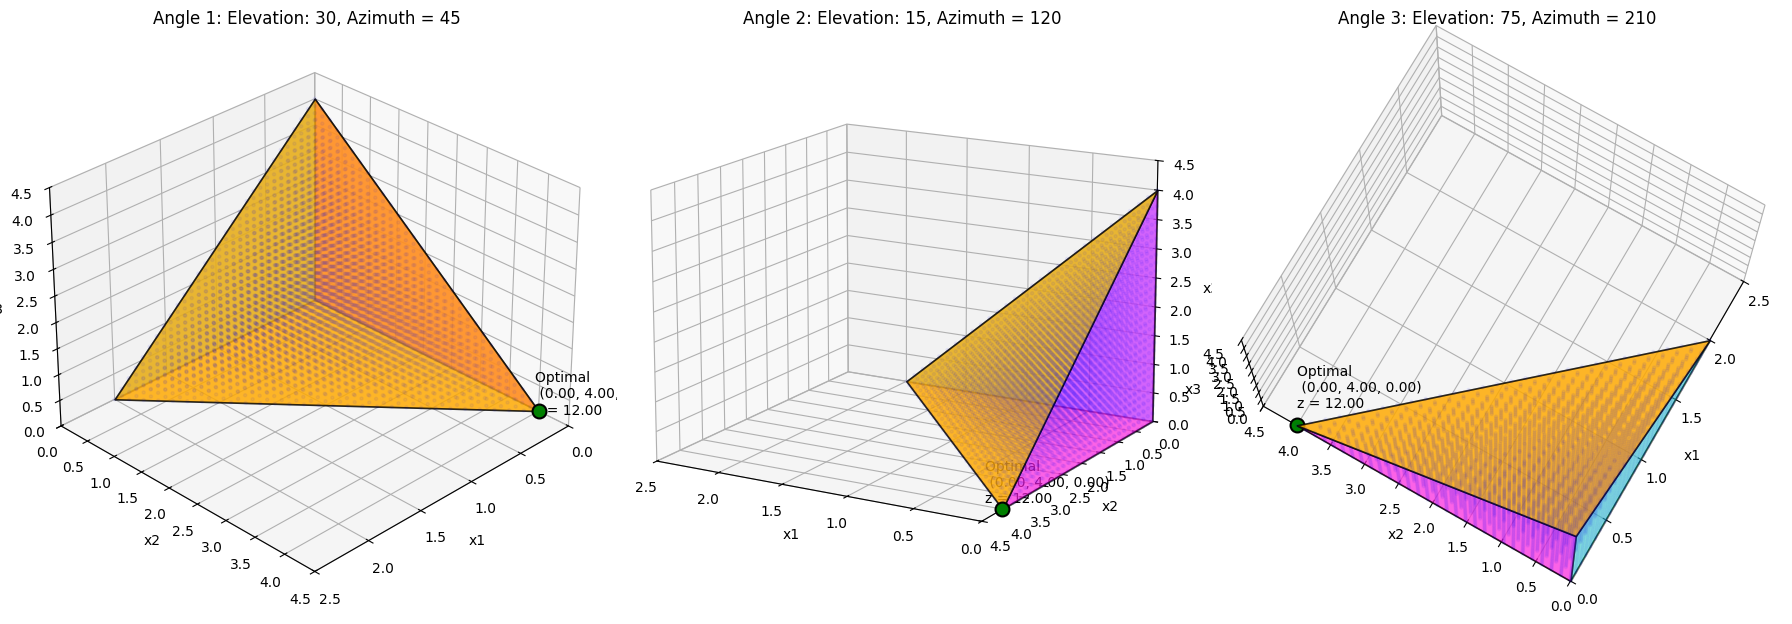

In [ ]:
fig = plt.figure(figsize = (18, 6))
view_angles = [(30, 45), (15, 120), (75, 210)]

titles = [
    'Angle 1: Elevation: 30, Azimuth = 45',
    'Angle 2: Elevation: 15, Azimuth = 120',
    'Angle 3: Elevation: 75, Azimuth = 210',
]

for i, (elev, azim) in enumerate(view_angles):
  ax = fig.add_subplot(1, 3, i + 1, projection = '3d')

  for (face, color, alpha) in zip(faces, faces_colors, face_alpha):
    poly = [vertices[j] for j in face]
    ax.add_collection3d(
        Poly3DCollection(
            [poly],
            alpha = alpha,
            facecolor = color,
            edgecolor = 'black',
            linewidths = 1.2
        )
    )

  ax.scatter(feasible_points[:, 0], feasible_points[:, 1], feasible_points[:, 2],
            color = 'blue', alpha = 0.05, s = 5)

  if model.success and len(model.x) == 3:
    x1, x2, x3 = model.x
    ax.scatter([x1], [x2], [x3], color = 'green',  s = 100, edgecolor = 'black',
              linewidths = 1.5)

    ax.text(x1 + 0.1, x2 + 0.1, x3 + 0.1,
            f'Optimal \n ({x1:.2f}, {x2:.2f}, {x3:.2f}) \nz = {-model.fun:.2f}', fontsize = 10)

  ax.set_xlabel('x1')
  ax.set_ylabel('x2')
  ax.set_zlabel('x3')
  ax.set_xlim(0, 2.5)
  ax.set_ylim(0, 4.5)
  ax.set_zlim(0, 4.5)

  ax.view_init(elev = elev, azim = azim)
  ax.set_title(titles[i])

plt.tight_layout()
plt.show()